## 목표설정
- 환자 데이터를 바탕으로 유방암인지 아닌지를 예측해보자.
- 딥러닝에서 이진분류를 진행하는 방법을 사용해보자.
- 사이킷런에 있는 유방암 데이터를 활용해서 양성 / 음성인지를 예측해보자.

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# 데이터셋 가져오기
from sklearn.datasets import load_breast_cancer

### 유방암 데이터에 대한 정보
- 위스콘신 대학교 의료 연구진이 만든 데이터
- 머신러닝 / 딥러닝 에서 이진분류 학습을 할 때 가장 많이 사용되는 데이터
- 전체 데이터 569개(악성종양 : 212 / 양성종양 : 357)


### 🎗️ 위스콘신 유방암 데이터셋 (Diagnostic) 변수 정의서

이 데이터셋은 각 세포 핵의 특성에 대해 **평균(Mean)**, **표준오차(Standard Error)**, **최악값(Worst, 큰 값 3개의 평균)**의 3가지 지표를 제공하여 총 30개의 특성(10개 항목 × 3개 지표)으로 구성됩니다.

| 분류 | 변수명 (영문) | 설명 | 비고 |
| :--- | :--- | :--- | :--- |
| **기본 크기** | `radius` | 중심에서 외곽까지의 거리 | 면적과 높은 상관관계 |
| | `perimeter` | 종양의 전체 둘레 | - |
| | `area` | 종양의 단면적 | - |
| **세부 모양** | `smoothness` | 반지름 길이의 국소적 변화 정도 | 표면의 매끄러움 |
| | `compactness` | $perimeter^2 / area - 1.0$ | 조밀도 |
| | `concavity` | 윤곽의 오목한 부분의 정도 | 오목함의 깊이 |
| | `concave points` | 윤곽의 오목한 부분의 개수 | - |
| **기하학적 구조** | `symmetry` | 세포의 대칭성 수준 | - |
| | `fractal dimension` | "해안선 근사" - 1 | 구조적 복잡도 |
| **표면 특성** | `texture` | 회색조 값의 표준편차 | 질감의 거칠기 |

In [9]:
cancer = load_breast_cancer()

In [10]:
cancer.keys()
# 'data' : 문제 데이터 / 특성값
# 'target' : 정답
# 'frame' : 0 / 1 - 이진분류
# 'target_names' : 정답의 실제 이름 (악성 - 0 / 양성 - 1)
# 'feature_names' : 특성의 실제 이름
# 'DESCR' : 데이터에 대한 설명서

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [11]:
# 문제 데이터 구성
# 데이터 프레임 형태로 구현 / 컬럼명은 특성의 실제 이름을 반영
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# 정답 데이터 살펴보기
y = cancer['target']
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [ ]:
# 정답의 실제 이름 살펴보기
cancer['target_names']
# 'malignant' : 악성 종양
# 'benign' : 양성 종양

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
# 데이터분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df,y,
                                                    random_state=10,
                                                    test_size = 0.3
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((398, 30), (171, 30), (398,), (171,))

In [ ]:
X_train.info()
# 결측치 X / 데이터 타입 : 실수형 - 인코딩 필요 X

<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 431 to 265
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              398 non-null    float64
 1   mean texture             398 non-null    float64
 2   mean perimeter           398 non-null    float64
 3   mean area                398 non-null    float64
 4   mean smoothness          398 non-null    float64
 5   mean compactness         398 non-null    float64
 6   mean concavity           398 non-null    float64
 7   mean concave points      398 non-null    float64
 8   mean symmetry            398 non-null    float64
 9   mean fractal dimension   398 non-null    float64
 10  radius error             398 non-null    float64
 11  texture error            398 non-null    float64
 12  perimeter error          398 non-null    float64
 13  area error               398 non-null    float64
 14  smoothness error         398 

In [ ]:
# 데이터 준비완료
# 신경망 구현
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

In [ ]:
# 뼈대 설정
model = Sequential()

# 입력층 구현
model.add(InputLayer(shape = (30,)))

# 중간 은닉층 구현
model.add(Dense(units=64, activation='sigmoid'))
model.add(Dense(units=32, activation='sigmoid'))
model.add(Dense(units=16, activation='sigmoid'))

# 출력층
model.add(Dense(units=1, activation='sigmoid'))

In [ ]:
# 모델 컴파일 - 학습 방법 및 평가 방법 설정
model.compile(
    loss = 'binary_crossentropy', # 이진 교차 엔트로피
    optimizer = 'SGD', # 확률적 경사하강법
    metrics = ['accuracy'] # 평가지표는 정확도
)

# 이진교차 엔트로피('binary_crossentropy')
# 분류문제에서 모델의 예측이 실제 정답과 얼마나 다른지 정량화 시키는 손실함수
# 퀴즈를 진행 할 때
# -> 자신있게 맞추면 벌점이 0점
# -> 긴가민가 헷갈리면서 맞추면 벌점이 조금 생김
# -> 자신있게 오답을 말하는 경우 벌점이 크게 생김
# 벌점 집계를 가지고 학습이 잘 되었는가를 보는 함수
# 인공지능이 학습을 잘 못 했을때 이거 잘못 한거야 크게 보정을 하기 위해 사용하는 함수

In [ ]:
# 모델 학습
h = model.fit(X_train, y_train, epochs=300)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3844 - loss: 0.7451  
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3844 - loss: 0.7124 
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4749 - loss: 0.6941 
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6583 - loss: 0.6829 
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6156 - loss: 0.6761  
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6156 - loss: 0.6702 
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6156 - loss: 0.6673 
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6156 - loss: 0.6657 
Epoch 9/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6156 - loss: 0.6641 
Epoch 10/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6156 - loss: 0.6632 
Epoch 11/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6156 - loss: 0.6624 
Epoch 12/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

In [ ]:
h.history
# 1번째 딕셔너리 값 : 정확도
# 2번째 딕셔너리 값 : 에러값

# 교차검증 진행 했을때 (현재는 진행하지 않음)
# 3번째 딕셔너리 값 : 검증 정확도
# 4번째 딕셔너리 값 : 검증 에러값

# 시각화 할때 자주 사용함

{'accuracy': [0.3844221234321594,
  0.3844221234321594,
  0.4748743772506714,
  0.6582914590835571,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406,
  0.6155778765678406

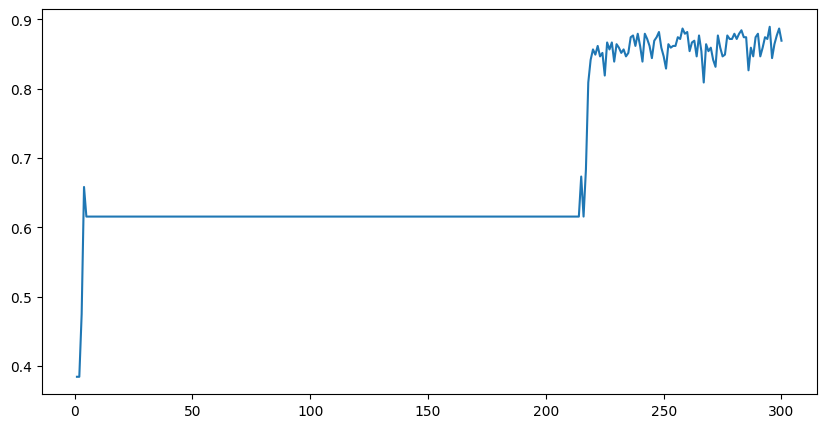

In [ ]:
# 정확도 변화율을 시각화 해보자
plt.figure(figsize=(10,5))
plt.plot(
    range(1, 301),
    h.history['accuracy'])
plt.show()

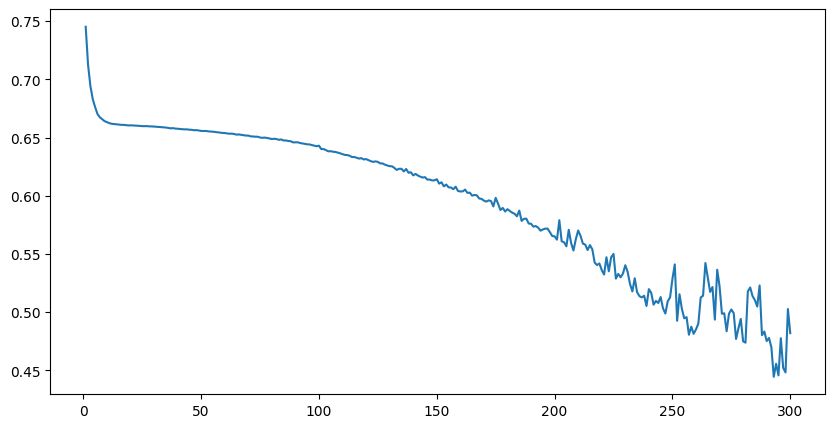

In [ ]:
# 에러 변화율을 시각화 해보자
plt.figure(figsize=(10,5))
plt.plot(
    range(1, 301),
    h.history['loss'])
plt.show()